In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
df = pd.read_pickle('/home/paolo/Na_dataset/diffusion.pckl.gzip', compression='gzip')

In [3]:
df

,structure,atoms,D_sim,D_300K,Ea,D0,r,D_sim_std,atoms_diffusion,diffusion_temps,...,VPA,NBI,RBI,weighted_electronegativity,FV,Na_spacing,Na_former_ratio,Na_anion_ratio,log_conductivity,logD
0,"[[-40.55755644 -31.11690268 -12.78408373] Na, ...","(Atom('Na', [-40.557556437030854, -31.11690267...","[1.4364625631071203e-07, 1.951308390440328e-06...",0.0,0.41481,-6.168029,-0.999534,"[2.0609274977491014e-08, 9.54751980775219e-08,...","[(Atom('Na', [16.4013, 25.9231, 16.2528], mome...","[500, 700, 900, 1100]",...,30.092044,0.672310,3.270586,2.779514,16.271870,5.009553,0.818182,0.239362,-6.802830,-22.213615
1,"[[-27.22272146 -48.08938883 -1.16173696] Na, ...","(Atom('Na', [-27.222721459416434, -48.08938883...","[5.260053344200803e-08, 4.0005952618958283e-07...",0.0,0.342211,-8.892149,-0.998229,"[1.170380927951024e-08, 3.5028882907097395e-08...","[(Atom('Na', [22.3934, 1.16212, 24.5241], mome...","[500, 700, 900, 1100]",...,28.802260,0.534658,1.160079,2.334804,9.578810,4.023160,0.851852,0.442308,-6.060846,-22.129469
2,"[[ -8.75124573 -35.84817417 1.41113688] Na, ...","(Atom('Na', [-8.751245728991412, -35.848174165...","[4.1491531541234836e-07, 2.9527838854461532e-0...",0.0,0.309818,-7.538836,-0.999465,"[4.712111654890927e-08, 1.5290730622277523e-07...","[(Atom('Na', [21.1725, 23.88, 1.00372], moment...","[500, 700, 900, 1100]",...,41.988188,0.418590,3.717974,2.110441,16.853349,4.911786,0.818182,0.387931,-4.053234,-19.523147
3,"[[ 5.90065301 -22.92956849 38.91278713] Na, ...","(Atom('Na', [5.900653007410151, -22.9295684907...","[3.644390884127098e-07, 2.282692400171146e-06,...",0.0,0.336138,-7.142088,-0.995077,"[2.3186241807603783e-08, 7.300603522025543e-08...","[(Atom('Na', [6.08525, 5.03001, 8.8188], momen...","[500, 700, 900, 1100]",...,44.180268,0.459960,12.327698,1.925347,13.252481,3.934283,2.846154,0.725490,-4.008862,-20.144502
4,"[[-19.7964428 -12.94618545 -22.08417706] Na, ...","(Atom('Na', [-19.79644280037215, -12.946185446...","[6.07698230883191e-08, 2.0869815246937256e-07,...",0.0,0.364908,-8.508542,-0.964053,"[1.548478587054459e-08, 3.1640692055019905e-08...","[(Atom('Na', [3.56707, 11.3108, 1.84764], mome...","[500, 700, 900, 1100]",...,21.846223,0.603340,1.635307,2.640404,9.327898,4.334335,0.492537,0.268293,-6.778690,-22.623812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,"[[-45.16852818 -78.13919154 20.16465523] Na, ...","(Atom('Na', [-45.16852817712178, -78.139191541...","[3.297906167882209e-06, 1.8844573960753516e-05...",0.0,0.247734,-6.836898,-0.999179,"[9.792967224616881e-08, 3.9756638417401317e-07...","[(Atom('Na', [21.5008, 25.8636, 21.0757], mome...","[500, 700, 900, 1100]",...,51.279798,0.503579,9.309462,2.179317,22.017312,4.934985,1.828571,0.426667,-0.963887,-16.419663
1300,"[[ 27.78664333 -31.36783786 -24.2354884 ] Na, ...","(Atom('Na', [27.786643333402175, -31.367837857...","[9.156914520012137e-07, 5.1272087089512735e-06...",0.0,0.283584,-7.370918,-0.998882,"[4.870329640437488e-08, 1.4125831290277235e-07...","[(Atom('Na', [-1.42491, -1.18625, 5.80358], mo...","[500, 700, 900, 1100]",...,47.672488,0.587851,2.941818,2.144747,15.234442,3.981873,2.846154,0.755102,-2.240883,-18.340452
1301,"[[ 9.75765064 -22.01865729 14.7129202 ] Na, ...","(Atom('Na', [9.757650639408531, -22.0186572933...","[1.8383356363262403e-07, 1.3151544777712655e-0...",0.0,0.326622,-7.991634,-0.998646,"[1.634566553839534e-08, 5.978999364457793e-08,...","[(Atom('Na', [10.255, 6.08899, 15.3406], momen...","[500, 700, 900, 1100]",...,42.832632,0.457983,1.896230,1.958541,11.402734,3.826133,1.857143,0.764706,-4.406686,-20.625948
1302,"[[-39.37930038 -62.24010789 -38.49384248] Na, ...","(Atom('Na', [-39.37930038383808, -62.240107891...","[8.887014627167615e-07, 6.4231800149440465e-06...",0.0,0.297862,-7.015121,-0.999876,"[4.980311200542334e-08, 2.1804315739470145e-07...","[(Atom('Na', [22.5873, 0.0336273, 22.6647], mo...","[500, 700, 900, 1100]",...,39.816525,0.617591,3.275683,2.479636,17.560774,4.69335

In [4]:
df.columns

Index(['structure', 'atoms', 'D_sim', 'D_300K', 'Ea', 'D0', 'r', 'D_sim_std',
       'atoms_diffusion', 'diffusion_temps', 'formula', 'composition', 'B%',
       'N%', 'O%', 'F%', 'Na%', 'Al%', 'Si%', 'P%', 'S%', 'Cl%', 'Ge%', 'Br%',
       'I%', 'density', 'AAV', 'PF', 'SBI', 'VPA', 'NBI', 'RBI',
       'weighted_electronegativity', 'FV', 'Na_spacing', 'Na_former_ratio',
       'Na_anion_ratio', 'log_conductivity', 'logD'],
      dtype='object')

In [5]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
kb

8.617333262e-05

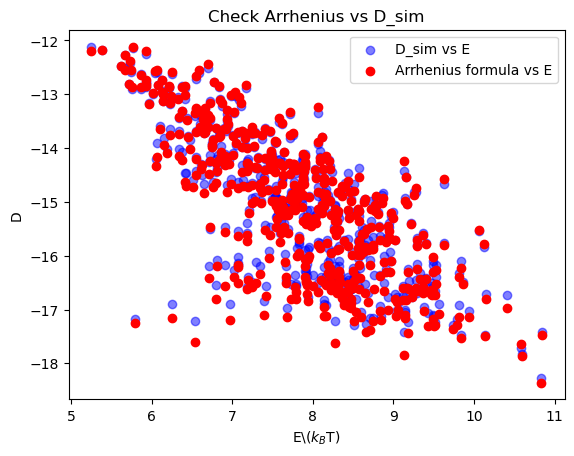

In [32]:
plt.scatter(E , np.log(D), alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , D0 - E, color = 'red', label = 'Arrhenius formula vs E')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.title('Check Arrhenius vs D_sim')
plt.show()

[[-16.21979104 -13.87295674 -12.56915991 -11.73947102]]


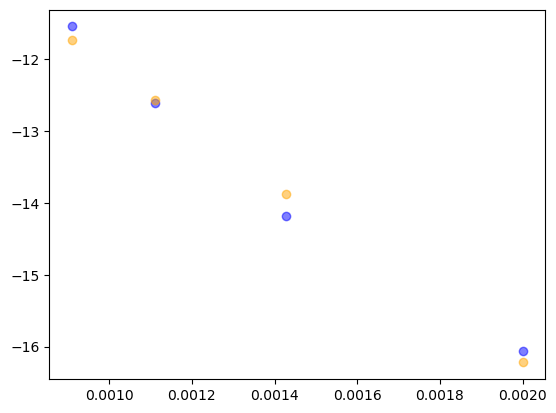

In [33]:
D_sim = np.array([df['D_sim'][100]])
temps = np.array([df['diffusion_temps'][100]])
D0 = np.array([df['D0'][100]])
E = np.array([df['Ea'][100]])
logD = D0 - E/(kb*temps)
print(logD)
plt.scatter(1/temps , np.log(D_sim), alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(1/temps , logD, alpha = 0.5, color = 'orange', label = 'D_sim vs E')
plt.show()

# Test SISSO

In [6]:
i = 0
D = np.array(df['D_sim'].str[i])[:500]
T = np.array(df['diffusion_temps'].str[i])[:500]
E = np.array(df['Ea'], dtype = 'float')[:500]/(kb*T)
D0 = np.array(df['D0'], dtype = 'float')[:500]

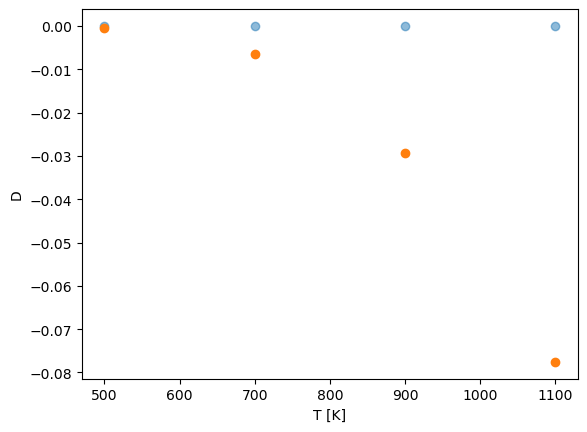

In [7]:
t_array = np.array(df['diffusion_temps'][0])
E0 = np.array(df['Ea'][0], dtype = 'float')/kb
plt.scatter(t_array , np.array(df['D_sim'][0]), alpha = 0.5)
plt.scatter(t_array , df['D0'][0]*np.exp(-E0/t_array))
plt.xlabel('T [K]')
plt.ylabel('D')
plt.show()

In [11]:
DvsE = pd.DataFrame({"sample_id": [f"s{i+1}" for i in range(len(D))], 'E/T': E, 'D': D})

In [12]:
DvsE.to_csv("/home/paolo/Thesis/Na/data/Na_diff.csv", index=False)
data_file = "/home/paolo/Thesis/Na/data/Na_diff.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [294]:
# Try the fit with the exact functional form
Diff_json = {
    'data_file': data_file,
     'property_key': 'D',
     'desc_dim': 1,
     'n_sis_select': 15,
     'max_rung': 2,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open("/home/paolo/Thesis/Na/data/diff.json", "w"), indent=4)

## Fitting D with Ea

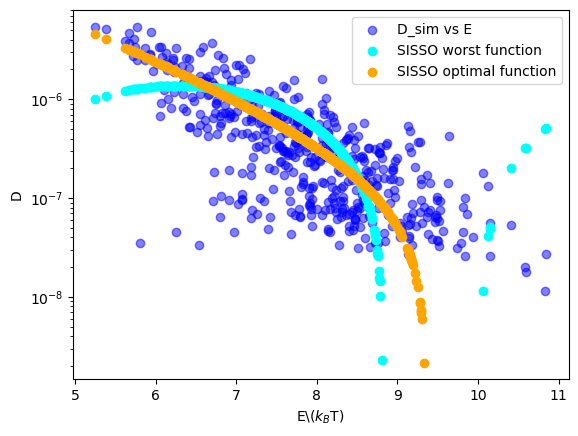

In [8]:
opt_funct = 1.704458640741253e-04*E/np.exp(E) - 1.390360191953970e-07
worst_funct = 7.570330401562866e-07*np.cos(E) +  6.191808278717039e-07 
plt.scatter(E , D, alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , worst_funct, color = 'cyan', label = 'SISSO worst function')
plt.scatter(E, opt_funct, label='SISSO optimal function', color = 'orange')
plt.yscale('log')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

## Fitting ln(D) with Ea

Expected Arrhenius like behaviour
$$
    ln(D) = ln(D_0) - E/(k_b*T)
$$

c0 is similar to the mean of the $D_0$ column values. a0 is close to $-1$

In [34]:
np.mean(D0)

-8.005871010825834

# PySR

In [22]:
# default_pysr_params = dict(
#     populations=30,
#     model_selection="best",
# )

In [23]:
# model = PySRRegressor(
#     niterations=500,
#     populations=50,
#     binary_operators=["+", "*", "/", "-"],
#     unary_operators=["square", "cos", "sin", "exp"],
#     maxdepth = 2,
#     #maxsize = 100
# )
# model.fit(E.reshape(-1, 1), D, variable_names=["E_T"])

Fit performed using E/(kb*T) as feature

In [20]:
model = PySRRegressor.from_file(
    run_directory="./outputs/20251226_100747_T4PKE5"
)

Attempting to load model from outputs/20251226_100747_T4PKE5/checkpoint.pkl...


In [21]:
model.sympy()

0.0009779291/exp(E_T)

Using Ea as feature and trying to obtain an estimate of kb*T with kb in eV/K and T=500 K

In [24]:
Ea = np.array(df['Ea'], dtype = 'float')[:500]

In [27]:
# # SEED = 42
# # np.random.seed(SEED)
# # random.seed(SEED)
# model2 = PySRRegressor(
#     niterations=300,
#     populations=50,
#     binary_operators=["+", "*", "/", "-"],
#     unary_operators=["cos", "sin", "exp"],
#     maxdepth = 10,
#     #maxsize = 100
# )
# model2.fit(Ea.reshape(-1, 1), D, variable_names=["Ea"])

In [25]:
model2 = PySRRegressor.from_file(
    run_directory="./outputs/20251216_100215_zKxHVD"
)

Attempting to load model from outputs/20251216_100215_zKxHVD/checkpoint.pkl...


In [26]:
sympy.simplify(model2.sympy())

0.001585507*exp(-24.990032*Ea)

In [11]:
1/(kb*500)

23.20903624310016

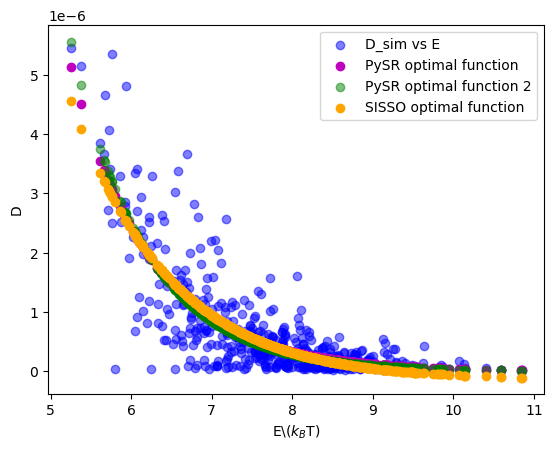

In [30]:
opt_funct = 1.704458640741253e-04*E/np.exp(E) - 1.390360191953970e-07
pysr_fuct =  0.000977952*np.exp(-E)
pysr_fuct2 =  0.001585507*np.exp(-24.990032*Ea)
plt.scatter(E , D, alpha = 0.5, color = 'blue', label = 'D_sim vs E')
plt.scatter(E , pysr_fuct, color = 'm', label = 'PySR optimal function')
plt.scatter(E , pysr_fuct2, alpha = 0.5, color = 'g', label = 'PySR optimal function 2')
plt.scatter(E, opt_funct, label='SISSO optimal function', color = 'orange')
plt.xlabel(r'E\($k_B$T)')
plt.ylabel('D')
plt.legend()
plt.show()

In [28]:
model3 = PySRRegressor.from_file(
    run_directory="./outputs/20251216_102840_Wws8Gg"
)

Attempting to load model from outputs/20251216_102840_Wws8Gg/checkpoint.pkl...


In [29]:
sympy.simplify(model3.sympy())

0.0019560584*exp(-25.7629703674315*Ea)